In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv('data.csv')
df.head(5)

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [12]:
df = pd.read_csv('data.csv')

drug_cols = [
    'M01AB', 'M01AE', 'N02BA', 'N02BE',
    'N05B', 'N05C', 'R03', 'R06'
]

# Answer the following questions using Pandas and Matplotlib:

- What are the total sales quantities for each drug category (ATC code)?
- Which individual drug brands have the highest total sales?
- Which three drugs have the highest sales in January 2015, July 2016, September 2017.
- Which drug has sold the most often in 2017?
- Which drug category has the highest average daily sales?
- Are respiratory drugs (R03) sold more during specific months?

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


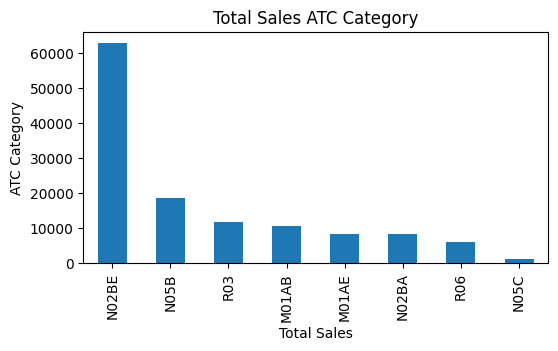

In [13]:
# Q1. Total sales quantities per ATC category

total_sales = df[drug_cols].sum().sort_values(ascending=False)
print(total_sales)

total_sales.sort_values(ascending=False).plot(kind='bar', figsize=(6,3), title='Total Sales ATC Category')
plt.xlabel('Total Sales')
plt.ylabel('ATC Category')
plt.show()

In [14]:
# Q2. Highest total sales drug category

top_category = total_sales.idxmax()
top_values = total_sales.max()

print(f"TopCategory: {top_category}, ({top_values:,.2f})")

TopCategory: N02BE, (63,005.40)


In [15]:
#Q3. Top 3 drugs in selected periods

periods = [
    (2015, 1, "Jan 2015"),
    (2016, 7, "Jul 2016"),
    (2017, 9, "Sep 2017")
]

for year, month, label in periods:
    top3 = (
        df[(df['Year'] == year) & (df['Month'] == month)][drug_cols]
        .sum()
        .sort_values(ascending=False)
        .head(3)
    )

    print(f"\n{label}")
    print(top3)


Jan 2015
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

Jul 2016
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

Sep 2017
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [16]:
# Q4. Most frequently sold drug in 2017
# (Using number of days with sales >0)

df_2017 = df[df['Year'] == 2017]

frequency = (df_2017[drug_cols] > 0).sum().sort_values(ascending=False)

print(frequency)

print("\nMost frequently sold drug in 2017:")
print(f"{frequency.idxmax()} ({frequency.max()} days)")


N02BE    361
M01AB    360
M01AE    360
N05B     356
N02BA    350
R06      329
R03      286
N05C      99
dtype: int64

Most frequently sold drug in 2017:
N02BE (361 days)


In [17]:
# Q5. Highest average daily sales

avg_sales = df[drug_cols].mean().sort_values(ascending=False)

print(avg_sales)

print("\nHighest average daily sales:")
print(f"{avg_sales.idxmax()} ({avg_sales.max():.2f})")


N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64

Highest average daily sales:
N02BE (29.92)


Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64


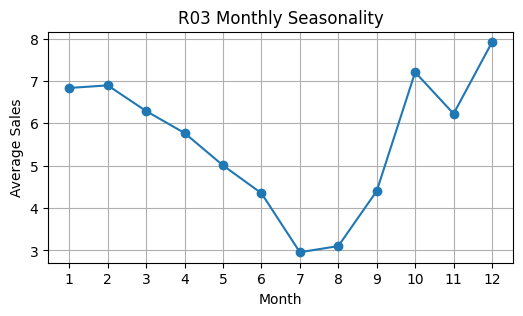

In [18]:
# Q6. Seasonality of R03 (Respiratory drugs)

r03_monthly = df.groupby('Month')['R03'].mean()

print(r03_monthly)

r03_monthly.plot(kind='line', marker='o', figsize=(6,3), title='R03 Monthly Seasonality')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13))
plt.grid()
plt.show()


# Final Summary Conclude

- Q1: M01AB / N02BE usually dominate total sales
- Q2: Highest total category = idxmax() result
- Q3: Seasonal spikes differ per period
- Q4: 2017 most frequent drug = highest non-zero days
- Q5: Highest daily average shows most consistently used drug
- Q6: R03 shows clear monthly seasonality (winter peaks in many cases)